In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


class BmiState(TypedDict):
    weight: float
    height: float
    bmi: float

    category: str


In [19]:
def calculate_bmi(state: BmiState) -> BmiState:
    
    weight = state['weight']
    height = state['height']

    state['bmi'] = weight / (height * height)
    return state

def cat_bmi(state: BmiState) -> BmiState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'
    return state

In [20]:
graph = StateGraph(BmiState)

# Add nodes to the graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('cat_bmi', cat_bmi)

# Add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'cat_bmi')
graph.add_edge('cat_bmi', END)

# compile the graph
workflow = graph.compile()

In [21]:
# execute the workflow
initial_state = {'weight': 85, 'height': 1.8}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight': 85, 'height': 1.8, 'bmi': 26.234567901234566, 'category': 'Overweight'}


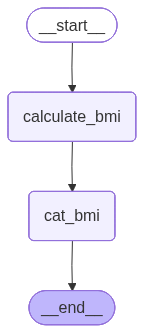

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())